# Importing some important library and create dataframe 

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as s
import datetime as datetime
df = pd.read_csv(r"C:/Users/Manas Tiwari/Downloads/Super_International_Market.csv",encoding = "latin 1")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          51290 non-null  int64  
 1   Order ID        51290 non-null  object 
 2   Order Date      51290 non-null  object 
 3   Ship Date       51290 non-null  object 
 4   Ship Mode       51290 non-null  object 
 5   Customer ID     51290 non-null  object 
 6   Customer Name   51290 non-null  object 
 7   Segment         51290 non-null  object 
 8   City            51290 non-null  object 
 9   State           51290 non-null  object 
 10  Country         51290 non-null  object 
 11  Postal Code     9994 non-null   float64
 12  Market          51290 non-null  object 
 13  Region          51290 non-null  object 
 14  Product ID      51290 non-null  object 
 15  Category        51290 non-null  object 
 16  Sub-Category    51290 non-null  object 
 17  Product Name    51290 non-null 

# first we have to change some datatype

In [274]:
df.dropna(inplace = True)
df["Order Date"] = pd.to_datetime(df["Order Date"], errors="coerce", dayfirst=True)
df["Ship Date"] = pd.to_datetime(df["Ship Date"], errors="coerce", dayfirst=True)

df["order_month"] = df["Order Date"].dt.month_name()

# drop null value

In [99]:
df.dropna(inplace =True)
df["month_num"] = df["Order Date"].dt.month


# Q.1 : You need to calculate the monthly sales of the store and identify which month had the highest sales and which month had the lowest sales.

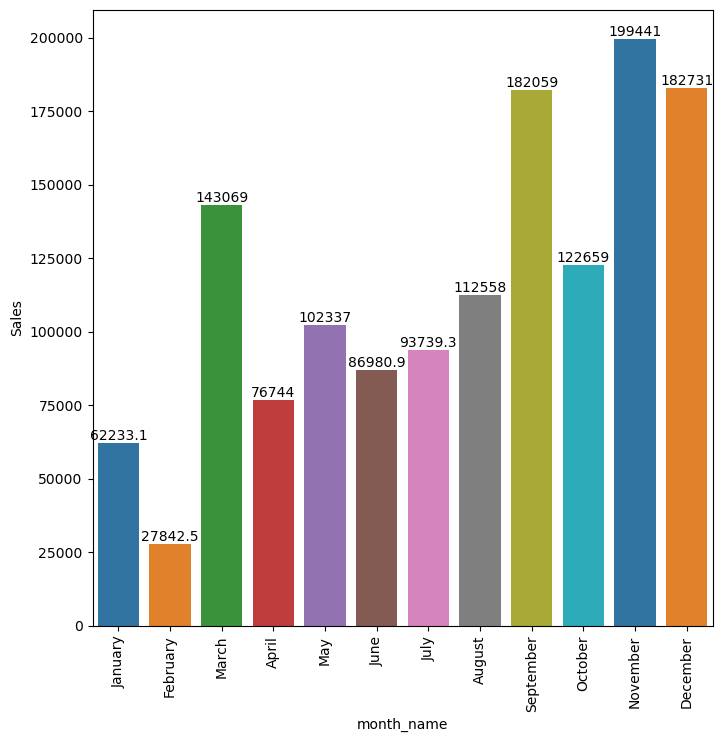

In [272]:
# Ensure order_date is datetime
df["Order Date"] = pd.to_datetime(df["Order Date"], errors='coerce')

# Extract month name and number
df["month_name"] = df["Order Date"].dt.strftime("%B")
df["month_num"] = df["Order Date"].dt.month

# Group and sort
gp = df.groupby(["month_name", "month_num"]).agg({"Sales": "sum"}).reset_index()
gp = gp.sort_values("month_num")

# Plot
plt.figure(figsize=(8, 8))
a = s.barplot(data=gp, x="month_name", y="Sales", hue="month_name", palette="tab10", legend=False)
for bars in a.containers:
    a.bar_label(bars)
plt.xticks(rotation=90)
plt.show()


conclusion : we can cliarly see that november month had highest sales and  februray month had the lowest sales.

# Q.2 : You need to analyze sales based on product categories and determine which category has the lowest sales and which category has the highest sales ??

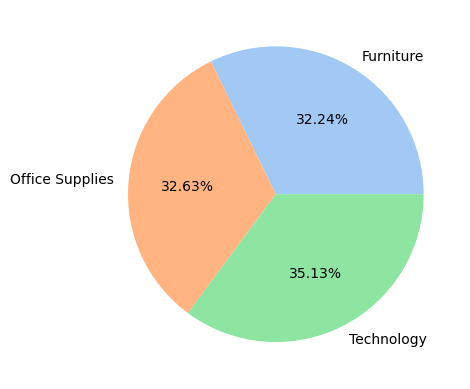

In [203]:
gp = df.groupby("Category")["Sales"].sum()
c = 	['#a1c9f4', '#ffb482', '#8de5a1', '#ff9f9b', '#d0bbff']
plt.pie(gp,labels = gp.index,autopct = "%1.2f%%",colors = c)
plt.show()

conclusion : we can see from the pie chart that Furniture category has the lowest sales and Technoogy category has the highest sales

# Q.3 : The sales analysis needs to be done based on sub-categories ??

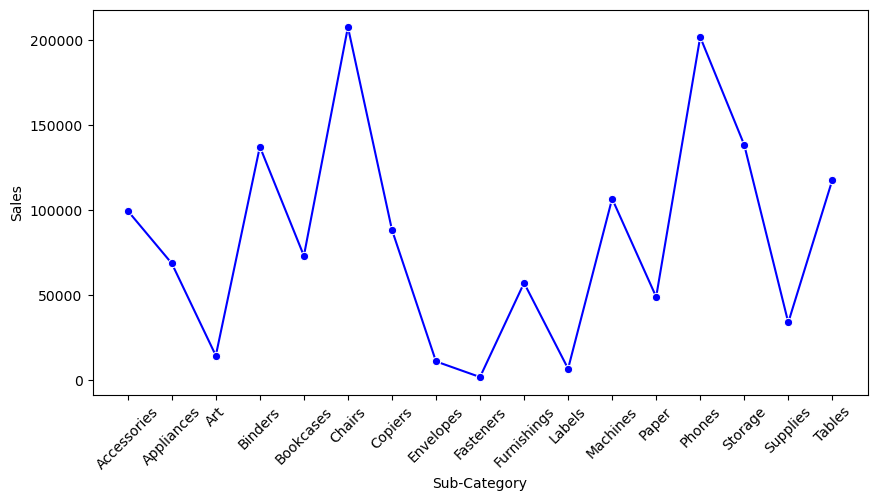

In [149]:
plt.figure(figsize=(10, 5))
gp = df.groupby("Sub-Category").agg({"Sales": "sum"}).reset_index()
s.lineplot(gp,x ="Sub-Category",y = "Sales",marker = "o",color = "blue")
plt.xticks(rotation = 45)
plt.show()

conclusion : we can see from the line graph that Art sub-category has the lowest sales and chairs sub-category has the highest sales

# Q.4 : You need to analyze the monthly profit from sales and determine which month had the highest profit??

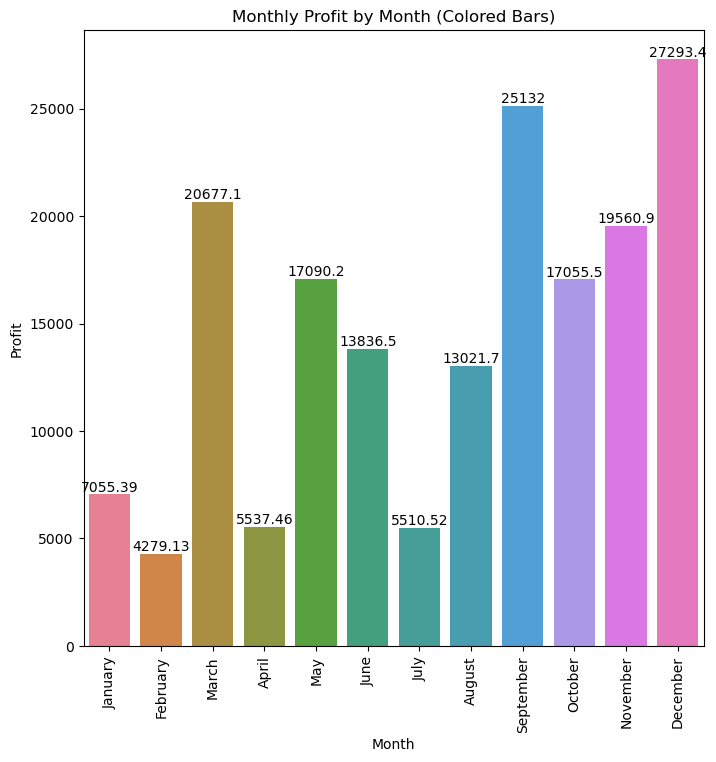

In [163]:
plt.figure(figsize=(8, 8))

# Set `hue` to "month_name" and disable legend
a = s.barplot(data=gp, x="month_name", y="Profit", hue="month_name", palette="husl", legend=False)

for bars in a.containers:
    a.bar_label(bars)

plt.xticks(rotation=90)
plt.title("Monthly Profit by Month (Colored Bars)")
plt.xlabel("Month")
plt.ylabel("Profit")
plt.show()


conclusion :  we can see from the bargraph that december month had the highest profit and february month had the lowest profit

# Q.5 : Analyze the profit by category and sub-category ??

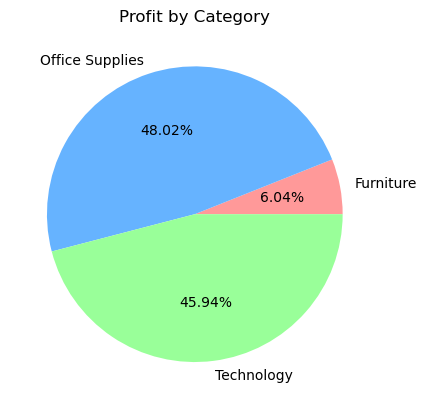

In [197]:
gp = df.groupby("Category")["Profit"].sum()
colors = ['#ff9999','#66b3ff','#99ff99','#ffcc99','#c2c2f0','#ffb3e6']  # or sns.color_palette('pastel')
plt.pie(gp, labels=gp.index, autopct="%1.2f%%", colors=colors)
plt.title("Profit by Category")
plt.show()


conclusion : we can see from the pie chart that Furniture category has the lowest profit and Office supplies category has the highest sales

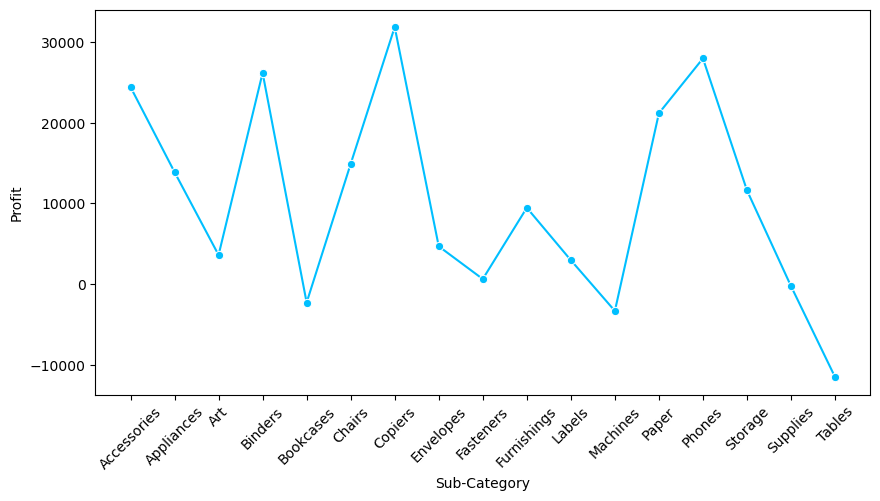

In [243]:
plt.figure(figsize=(10, 5))
gp = df.groupby("Sub-Category").agg({"Profit": "sum"}).reset_index()
s.lineplot(gp,x ="Sub-Category",y = "Profit",marker = "o",color = "#00bfff")
plt.xticks(rotation = 45)
plt.show()

conclusion : we can see from the line graph that Tables sub-category has the lowest Profit and Copiers sub-category has the highest Profit

# Q.6 :  Analyze the sales and profit by customer segment ??

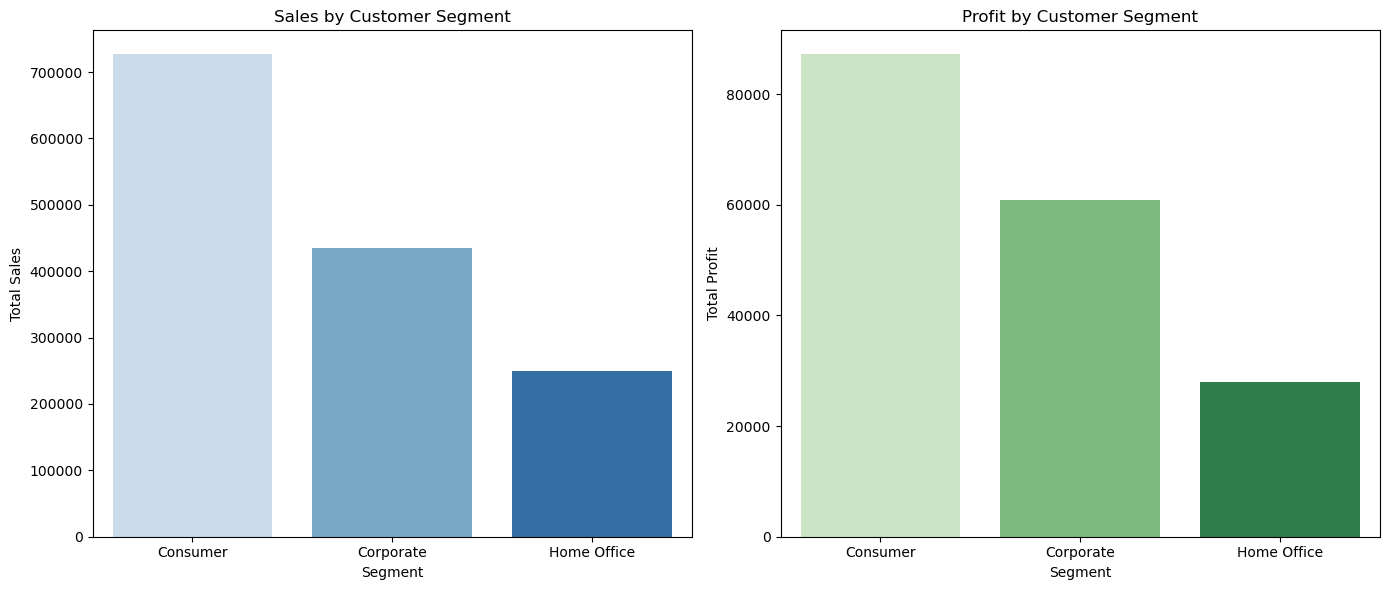

In [248]:
import matplotlib.pyplot as plt
import seaborn as sns

# Group data
gp = df.groupby("Segment")[["Sales", "Profit"]].sum().reset_index()

# Set figure size
plt.figure(figsize=(14, 6))

# Plot 1: Sales
plt.subplot(1, 2, 1)
sns.barplot(data=gp, x="Segment", y="Sales", hue="Segment", palette="Blues", legend=False)
plt.title("Sales by Customer Segment")
plt.xlabel("Segment")
plt.ylabel("Total Sales")

# Plot 2: Profit
plt.subplot(1, 2, 2)
sns.barplot(data=gp, x="Segment", y="Profit", hue="Segment", palette="Greens", legend=False)
plt.title("Profit by Customer Segment")
plt.xlabel("Segment")
plt.ylabel("Total Profit")

plt.tight_layout()
plt.show()


conclusion : The Consumer segment drives the highest sales and profit, while the Home Office segment contributes the least to both.

# Q.7 : Analyze the sales to profit ratio ??


In [267]:
gp = df.groupby("Segment").agg({"Sales":"sum","Profit":"sum"})
a = gp["Sales"]/gp["Profit"]
a

Segment
Consumer       8.336684
Corporate      7.150185
Home Office    8.919888
dtype: float64

conclusion : The Home Office segment is the most profitable, while the Corporate segment is the least.